In [80]:
import pandas as pd
import numpy as np

In [81]:
df=pd.read_csv("../data/cleaned_data.csv")

RFM Analysis

R-Recency: Refers to the number of days since customer's last purchase. 

F-Frequency: Refers to the number of unique orders from a customer

M-Monetary: Refers to the total monetory sales from a customer

In [82]:
#Convert the "Order Date" column to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])

# max() function finds the latest date in column
# adding a day to the latest date to get the reference date
# doing this avoids recent customer getting recency value as 0
reference_date = df["Order Date"].max() + pd.Timedelta(days=1)
print(reference_date)

2017-12-31 00:00:00


Latest Customer purchase is 30st December 2017 and referance considerd as 31st December 2017.

In [83]:
rfm=df.groupby("Customer ID").agg({ #group orders by same customers
    "Order Date": lambda x: (reference_date - x.max()).days, #recency 
    "Order ID": "nunique", #frequency of unique orders
    "Sales": "sum" #monetary value of total sales
})
#x is all orders from a customer
#x.max() gives the latest order date for that customer
# Recency=Reference Date-Customer's last purchase

In [84]:
rfm.columns=["Recency", "Frequency", "Monetary"]

Smaller the Recency value, more recent purchase by customer

More the Frequency value, more repeat customer

In [85]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,185,5,5563.560
AA-10375,20,9,1056.390
AA-10480,260,4,1790.512
AA-10645,56,6,5086.935
AB-10015,416,3,886.156


In [86]:
#Scaling RFM value to a range of 1-5 for each metric
#quantile function qcut() is used to segment the data into 5 equal parts
#labels from 5 to 1 because lower the recency value, higher the score and vice versa for frequency and monetary value
rfm["R_score"]=pd.qcut(
rfm["Recency"],
q=5,
labels=[5, 4, 3, 2, 1]
)

#rank(method="first") is used to rank the frequency value and aid in segmenting the data into 5 equal parts
#this helps replace dupllicate values with a unique rank keeping order same
rfm["F_score"]=pd.qcut(
rfm["Frequency"].rank(method="first"),
q=5,
labels=[1, 2, 3, 4, 5]
)

rfm["M_score"]=pd.qcut(
rfm["Monetary"],
q=5,
labels=[1, 2, 3, 4, 5]
)

In [87]:
#Bucket intervals to rank all the three metrics
pd.qcut(rfm["Recency"], q=5).unique()

[(104.0, 225.6], (0.999, 27.0], (225.6, 1166.0], (54.0, 104.0], (27.0, 54.0]]
Categories (5, interval[float64, right]): [(0.999, 27.0] < (27.0, 54.0] < (54.0, 104.0] < (104.0, 225.6] < (225.6, 1166.0]]

In [90]:
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score
Customer ID,,,,,,
AA-10315,185,5,5563.560,2,2,5
AA-10375,20,9,1056.390,5,5,2
AA-10480,260,4,1790.512,1,1,3
AA-10645,56,6,5086.935,3,3,5
AB-10015,416,3,886.156,1,1,1


In [92]:
#Converting scores to strings and concatenating them to create combined score
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

In [93]:
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
Customer ID,,,,,,,
AA-10315,185,5,5563.560,2,2,5,225
AA-10375,20,9,1056.390,5,5,2,552
AA-10480,260,4,1790.512,1,1,3,113
AA-10645,56,6,5086.935,3,3,5,335
AB-10015,416,3,886.156,1,1,1,111


In [94]:
def segment_customer(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Champion"
    elif row["R_score"] >= 3 and row["F_score"] >= 3:
        return "Loyal Customer"
    elif row["R_score"] >= 4:
        return "Recent Customer"
    elif row["F_score"] >= 4:
        return "Frequent Customer"
    else:
        return "Others"

In [96]:
#Function applied to the dataframe
#New column created for customer segment
#axis=1 refers to function being apllied to each row
rfm["Customer_Segment"]=rfm.apply(segment_customer, axis=1)

In [97]:
rfm.head(10)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Customer_Segment
Customer ID,,,,,,,,
AA-10315,185,5,5563.560,2,2,5,225,Others
AA-10375,20,9,1056.390,5,5,2,552,Loyal Customer
AA-10480,260,4,1790.512,1,1,3,113,Others
AA-10645,56,6,5086.935,3,3,5,335,Loyal Customer
AB-10015,416,3,886.156,1,1,1,111,Others
AB-10060,55,8,7755.620,3,4,5,345,Loyal Customer
AB-10105,42,10,14473.571,4,5,5,455,Champion
AB-10150,42,5,966.710,4,2,2,422,Recent Customer
AB-10165,26,8,1113.838,5,4,2,542,Loyal Customer


Visualization of RFM Analysis

In [101]:
segment_counts=rfm["Customer_Segment"].value_counts()
print(segment_counts)

Customer_Segment
Others               293
Loyal Customer       225
Champion             106
Recent Customer       89
Frequent Customer     80
Name: count, dtype: int64


In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Avani Bhartiya\AppData\Local\Temp\ipykernel_16540\668059915.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


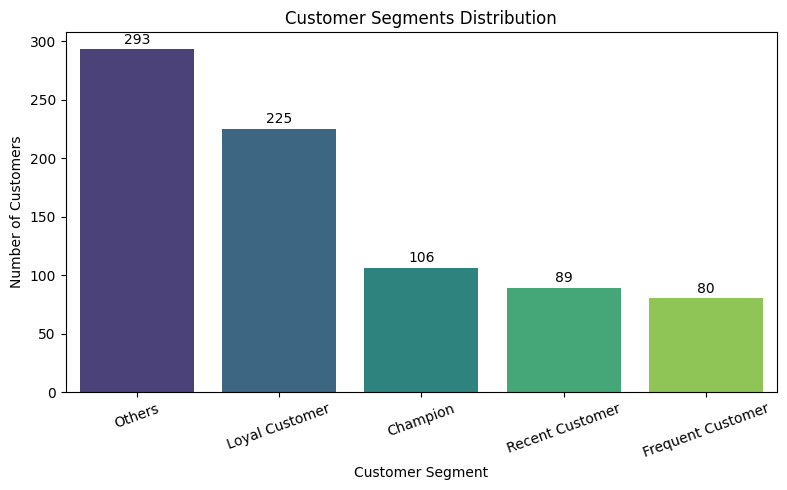

In [120]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values,
    palette="viridis",
)
plt.title("Customer Segments Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
for i, value in enumerate(segment_counts.values):
    plt.text(i, value + 5, str(value), ha="center")
plt.tight_layout()
plt.show()

1. Others (293 customers) – Largest Segment
- Nearly 37% of customers fall into the "Others" category.
- These customers don't currently meet the criteria for high-value segments.
- Action: Analyze them further to identify inactive customers, one-time buyers, or customers needing engagement.

2. Loyal Customers (225 customers)
- This is the second-largest segment.
- These customers purchase consistently and are valuable for long-term revenue.
- Action: Reward them with loyalty programs, memberships, or personalized recommendations.

3. Champions (106 customers)
- These are your highest-value customers.
- They purchase recently and frequently and satisfy your highest segment criteria.
- Action: Retain them with exclusive offers, VIP benefits, and early product access.

4. Recent Customers (89 customers)
- They have purchased recently but haven't yet become regular buyers.
- Action: Encourage repeat purchases through welcome discounts or follow-up emails.

5. Frequent Customers (80 customers)
- They buy often but may not spend much or may not have purchased very recently.
- Action: Increase their average order value through bundles, cross-selling, and premium product recommendations.

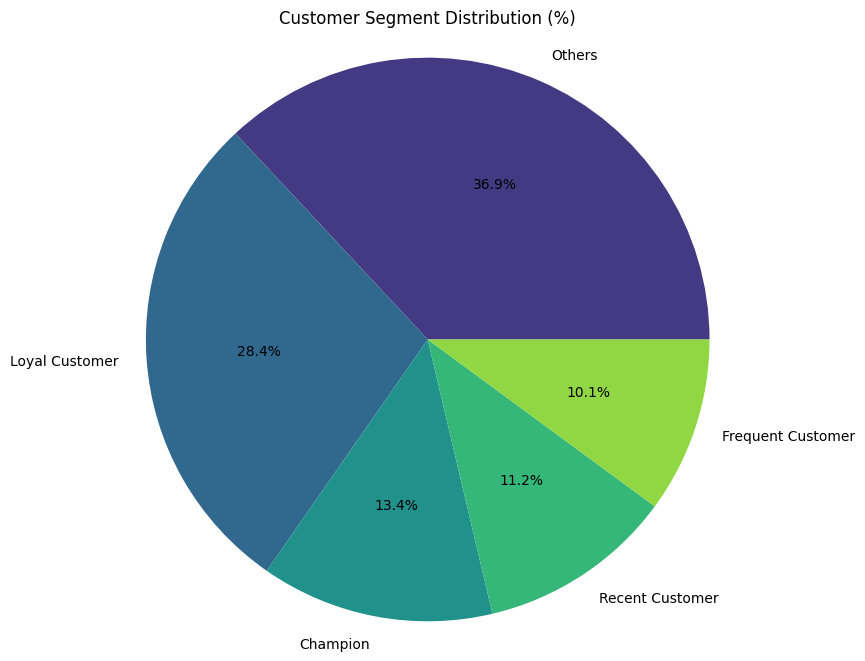

In [ ]:
#Pie Chart
plt.figure(figsize=(8,8))
plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("viridis", len(segment_counts))
)

plt.title("Customer Segment Distribution (%)")
plt.axis("equal")   

plt.show()

Business Insights
- Almost 37% of customers require further analysis or engagement.
- Nearly one-third of customers are already loyal, indicating healthy customer retention.
- Around 13% are Champions, which is a valuable group that contributes significantly to business performance.
- Recent and Frequent customers together make up over 20% of customers, presenting a strong opportunity for conversion into Loyal or Champion customers.

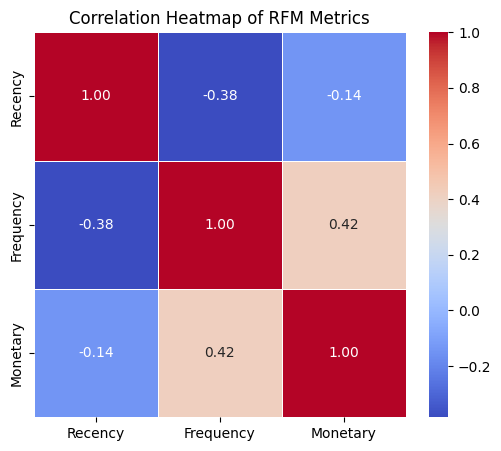

In [125]:
#HeatMap
plt.figure(figsize=(6,5))
#Creates a correlation matrix for the metrics +1 to -1
correlation = rfm[["Recency", "Frequency", "Monetary"]].corr()
sns.heatmap(
    correlation,
    annot=True, #print digits
    #red for positive correlation and blue for negative correlation
    cmap="coolwarm", 
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of RFM Metrics")
plt.show()

Recency vs Frequency = -0.38
- This is the strongest positive relationship in your heatmap.
- Customers who purchased more recently generally tend to purchase more frequently.

Recency vs Monetary = -0.14
- This is a weak negative relationship.
- Customers who purchased recently do not necessarily spend much more money.
- Therefore, spending isn't strongly linked with how recently someone purchased.

Frequency vs Monetary = 0.42
- This is a moderate positive relationship.
- Customers who buy more frequently generally spend more overall.